# Batch-Aware Spatial Multi-Omics Integration on Simulated Batch-Effect Data

This notebook replaces the real A1/D1 tissue pipeline with a **controlled synthetic experiment** designed to answer one question:

> **Does the MMD batch-alignment term in the model actually reduce batch effects while preserving biological structure?**

The experiment creates:
- multiple simulated spatial samples,
- two modalities per spot (RNA-like and protein-like),
- known biological domains,
- injected batch effects that shift the same biology across samples.

Then it trains the same model twice:

1. **No batch correction**
2. **MMD batch correction**

Because the ground truth is known, we can test whether MMD:
- improves **batch mixing**,
- reduces **sample separation**,
- and still preserves **true biological clusters**.

## 1. Imports and configuration
This section imports the model, defines reproducibility settings, and creates output folders.

In [1]:
import os
import sys
import random

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.neighbors import NearestNeighbors
from scipy.stats import entropy

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

OUT_DIR = "outputs/simulated_batch_mmd"
FIG_DIR = os.path.join(OUT_DIR, "figures")
TABLE_DIR = os.path.join(OUT_DIR, "tables")
MODEL_DIR = os.path.join(OUT_DIR, "models")

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

DEVICE = "cpu"

# Simulation and model settings
NUM_SAMPLES = 3
GRID_H = 18
GRID_W = 18
N_SPOTS_PER_SAMPLE = GRID_H * GRID_W
N_CLUSTERS = 4

IN_DIM = 30
HIDDEN_DIM = 64
LATENT_DIM = 16

SPATIAL_K = 6
FEATURE_K = 10

EPOCHS = 400
LR = 1e-3
LAMBDA_CORR = 1.0
LAMBDA_BATCH = 0.5

# ---------------------------------------------------------------------------
# Import SpatialGlueBatchAware
# Looks in: (1) same directory as this notebook, (2) current working directory.
# Place SpatialGlueBatchAware.py alongside the notebook before running.
# ---------------------------------------------------------------------------
_nb_dir = os.path.dirname(os.path.abspath(__file__)) if "__file__" in dir() else os.getcwd()
_search_paths = [_nb_dir, os.getcwd()]

_imported = False
for _p in _search_paths:
    if _p not in sys.path:
        sys.path.insert(0, _p)
    try:
        from SpatialGlueBatchAware import SpatialGlueMini, total_loss
        print(f"Imported SpatialGlueBatchAware from: {_p}")
        _imported = True
        break
    except ImportError:
        pass

if not _imported:
    raise ImportError(
        "SpatialGlueBatchAware.py not found.\n"
        f"Searched: {_search_paths}\n"
        "Copy SpatialGlueBatchAware.py into the same folder as this notebook and re-run."
    )

print(f"Total simulated spots: {NUM_SAMPLES * N_SPOTS_PER_SAMPLE}")


Imported SpatialGlueBatchAware from: c:\Users\imoha\OneDrive\Computational Biology SpatialGLUE\Project
Total simulated spots: 972


## 2. Helper functions
These helpers build graphs, generate synthetic spatial multi-omics data, train the model, and evaluate batch mixing and biological preservation.

In [2]:
def knn_edge_index(X, k):
    nbrs = NearestNeighbors(n_neighbors=k + 1).fit(X)
    _, indices = nbrs.kneighbors(X)
    edges = []
    for i in range(X.shape[0]):
        for j in indices[i, 1:]:
            edges.append([i, j])
    return torch.tensor(edges, dtype=torch.long).t().contiguous()

def offset_edge_index(edge_index, offset):
    return edge_index + offset

def pca_projection(X, n_components=2):
    pca = PCA(n_components=n_components, random_state=SEED)
    X2 = pca.fit_transform(X)
    return X2, pca.explained_variance_ratio_

def cluster_embedding(X, n_clusters=N_CLUSTERS, random_state=SEED):
    km = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=20)
    labels = km.fit_predict(X)
    return labels, km.cluster_centers_

def normalized_batch_entropy_score(embedding, batch_labels, k=30):
    embedding = np.asarray(embedding)
    batch_labels = np.asarray(batch_labels)

    k = min(k, len(embedding) - 1)
    nbrs = NearestNeighbors(n_neighbors=k + 1).fit(embedding)
    indices = nbrs.kneighbors(embedding, return_distance=False)[:, 1:]

    unique_batches = np.unique(batch_labels)
    max_entropy = np.log2(len(unique_batches)) if len(unique_batches) > 1 else 1.0
    entropies = []

    for neigh_idx in indices:
        neigh_batches = batch_labels[neigh_idx]
        counts = np.array([(neigh_batches == b).sum() for b in unique_batches], dtype=float)
        probs = counts / counts.sum()
        entropies.append(entropy(probs, base=2) / max_entropy if max_entropy > 0 else 0.0)

    return float(np.mean(entropies))

def evaluate_embedding(X, batch_labels, true_labels):
    X = np.asarray(X)
    batch_labels = np.asarray(batch_labels)
    true_labels = np.asarray(true_labels)

    pred_labels, _ = cluster_embedding(X, n_clusters=len(np.unique(true_labels)))
    metrics = {
        "batch_silhouette": silhouette_score(X, batch_labels),
        "biology_silhouette": silhouette_score(X, true_labels),
        "batch_entropy": normalized_batch_entropy_score(X, batch_labels, k=30),
        "ARI_vs_truth": adjusted_rand_score(true_labels, pred_labels),
        "NMI_vs_truth": normalized_mutual_info_score(true_labels, pred_labels),
    }
    return metrics, pred_labels

def make_spatial_domains(coords, h, w):
    x = coords[:, 0]
    y = coords[:, 1]

    # Four broad spatial regions with smooth-ish structure.
    labels = np.zeros(len(coords), dtype=int)
    labels[(x >= w / 2) & (y < h / 2)] = 1
    labels[(x < w / 2) & (y >= h / 2)] = 2
    labels[(x >= w / 2) & (y >= h / 2)] = 3

    # Add a mild nonlinear boundary so clusters are not perfectly rectangular.
    center_x = (w - 1) / 2
    center_y = (h - 1) / 2
    radius = np.sqrt((x - center_x) ** 2 + (y - center_y) ** 2)
    ring_mask = (radius > min(h, w) * 0.18) & (radius < min(h, w) * 0.28)
    labels[ring_mask] = (labels[ring_mask] + 1) % 4
    return labels

def simulate_sample(sample_id, grid_h, grid_w, in_dim, n_clusters):
    xs, ys = np.meshgrid(np.arange(grid_w), np.arange(grid_h))
    coords = np.column_stack([xs.ravel(), ys.ravel()]).astype(float)

    # Slight sample-specific geometric distortion to emulate non-identical tissues.
    coords = coords + np.random.normal(scale=0.15, size=coords.shape)
    coords[:, 0] += 0.10 * sample_id * np.sin(coords[:, 1] / 3.0)
    coords[:, 1] += 0.08 * sample_id * np.cos(coords[:, 0] / 4.0)

    true_labels = make_spatial_domains(coords, grid_h, grid_w)

    return coords, true_labels

def simulate_multimodal_batch_data(
    num_samples=NUM_SAMPLES,
    grid_h=GRID_H,
    grid_w=GRID_W,
    in_dim=IN_DIM,
    n_clusters=N_CLUSTERS,
):
    # Shared biological prototypes: same underlying biology across batches.
    base_rna = np.random.normal(0, 1.0, size=(n_clusters, in_dim))
    base_prot = base_rna * 0.65 + np.random.normal(0, 0.60, size=(n_clusters, in_dim))

    all_coords = []
    all_true = []
    all_sample_ids = []
    all_sample_names = []

    X_rna_list = []
    X_prot_list = []

    for sample_id in range(num_samples):
        coords, true_labels = simulate_sample(sample_id, grid_h, grid_w, in_dim, n_clusters)
        n = len(coords)

        # Sample-specific batch effects.
        # These are intentionally strong enough that the same biological domain
        # lands in different observed regions across samples.
        rna_shift = np.random.normal(loc=0.0, scale=2.0, size=(1, in_dim))
        prot_shift = np.random.normal(loc=0.0, scale=2.0, size=(1, in_dim))

        rna_scale = np.random.uniform(0.75, 1.35, size=(1, in_dim))
        prot_scale = np.random.uniform(0.75, 1.35, size=(1, in_dim))

        # Low-rank structured batch distortion.
        batch_vector = np.random.normal(size=(in_dim,))
        batch_vector = batch_vector / (np.linalg.norm(batch_vector) + 1e-8)
        spatial_axis = (coords[:, 0] - coords[:, 0].mean()) / (coords[:, 0].std() + 1e-8)
        structured_shift = 1.0 * np.outer(spatial_axis, batch_vector)

        # Shared biology + modality-specific observation noise.
        X_rna = base_rna[true_labels] + np.random.normal(scale=0.55, size=(n, in_dim))
        X_prot = base_prot[true_labels] + np.random.normal(scale=0.55, size=(n, in_dim))

        # Inject batch effect.
        X_rna = X_rna * rna_scale + rna_shift + structured_shift
        X_prot = X_prot * prot_scale + prot_shift - structured_shift

        # Mild nonlinear modality distortion.
        X_rna = X_rna + 0.10 * np.tanh(X_rna)
        X_prot = X_prot + 0.10 * np.sin(X_prot)

        all_coords.append(coords)
        all_true.append(true_labels)
        all_sample_ids.append(np.full(n, sample_id, dtype=int))
        all_sample_names.extend([f"sample_{sample_id}"] * n)

        X_rna_list.append(X_rna.astype(np.float32))
        X_prot_list.append(X_prot.astype(np.float32))

    coords_all = np.vstack(all_coords).astype(np.float32)
    true_labels_all = np.concatenate(all_true)
    sample_ids = np.concatenate(all_sample_ids)
    sample_names = np.array(all_sample_names)

    X_rna_all = np.vstack(X_rna_list).astype(np.float32)
    X_prot_all = np.vstack(X_prot_list).astype(np.float32)

    return {
        "X_rna_all": X_rna_all,
        "X_prot_all": X_prot_all,
        "coords_all": coords_all,
        "true_labels": true_labels_all,
        "sample_ids": sample_ids,
        "sample_names": sample_names,
        "X_rna_list": X_rna_list,
        "X_prot_list": X_prot_list,
        "coords_list": all_coords,
    }

def build_disconnected_spatial_graph(coords_list, k=SPATIAL_K):
    edges = []
    offset = 0
    for coords in coords_list:
        e = knn_edge_index(coords, k)
        edges.append(offset_edge_index(e, offset))
        offset += coords.shape[0]
    return torch.cat(edges, dim=1)

def build_disconnected_feature_graph(X_list, k=FEATURE_K):
    edges = []
    offset = 0
    for X in X_list:
        e = knn_edge_index(X, k)
        edges.append(offset_edge_index(e, offset))
        offset += X.shape[0]
    return torch.cat(edges, dim=1)

def train_with_history(
    model,
    xs,
    spatial_edge_index,
    feature_edge_indices,
    sample_ids=None,
    epochs=EPOCHS,
    lr=LR,
    lambda_corr=LAMBDA_CORR,
    lambda_batch=LAMBDA_BATCH,
    device=DEVICE
):
    model = model.to(device)
    xs = [x.to(device) for x in xs]
    spatial_edge_index = spatial_edge_index.to(device)
    feature_edge_indices = [e.to(device) for e in feature_edge_indices]
    sample_ids = sample_ids.to(device) if sample_ids is not None else None

    opt = torch.optim.Adam(model.parameters(), lr=lr)
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        opt.zero_grad()

        outputs = model(xs, spatial_edge_index, feature_edge_indices)
        loss, recon, corr, batch = total_loss(
            xs,
            outputs,
            sample_ids=sample_ids,
            lambda_corr=lambda_corr,
            lambda_batch=lambda_batch,
        )
        loss.backward()
        opt.step()

        history.append({
            "epoch": epoch,
            "total": float(loss.item()),
            "recon": float(recon.item()),
            "corr": float(corr.item()),
            "batch": float(batch.item()),
        })

        if epoch % 50 == 0 or epoch == 1:
            print(
                f"Epoch {epoch:04d} | total={loss.item():.4f} | "
                f"recon={recon.item():.4f} | corr={corr.item():.4f} | batch={batch.item():.4f}"
            )

    return model, pd.DataFrame(history)

def get_latent(model, xs, spatial_edge_index, feature_edge_indices):
    model.eval()
    with torch.no_grad():
        outputs = model(xs, spatial_edge_index, feature_edge_indices)
    return outputs["z"].cpu().numpy(), outputs

def sample_centroid_table(X2, batch_labels):
    rows = []
    for sid in np.unique(batch_labels):
        centroid = X2[batch_labels == sid].mean(axis=0)
        rows.append({"sample": int(sid), "PC1_centroid": centroid[0], "PC2_centroid": centroid[1]})
    return pd.DataFrame(rows)

## 3. Simulate spatial multi-omics data with known biology and injected batch effects
The same biological domains exist in every sample, but each sample receives a different batch shift, scale change, and structured distortion.

In [3]:
sim = simulate_multimodal_batch_data()

X_rna_all = sim["X_rna_all"]
X_prot_all = sim["X_prot_all"]
coords_all = sim["coords_all"]
true_labels = sim["true_labels"]
sample_ids = sim["sample_ids"]
sample_names = sim["sample_names"]

X_rna_list = sim["X_rna_list"]
X_prot_list = sim["X_prot_list"]
coords_list = sim["coords_list"]

print("RNA shape:", X_rna_all.shape)
print("Protein shape:", X_prot_all.shape)
print("Coords shape:", coords_all.shape)
print("True labels:", np.unique(true_labels))
print("Samples:", np.unique(sample_ids))

RNA shape: (972, 30)
Protein shape: (972, 30)
Coords shape: (972, 2)
True labels: [0 1 2 3]
Samples: [0 1 2]


## 4. Visualize the simulated tissue layout
These panels show the spatial coordinates colored by the **true biological domain** for each sample.

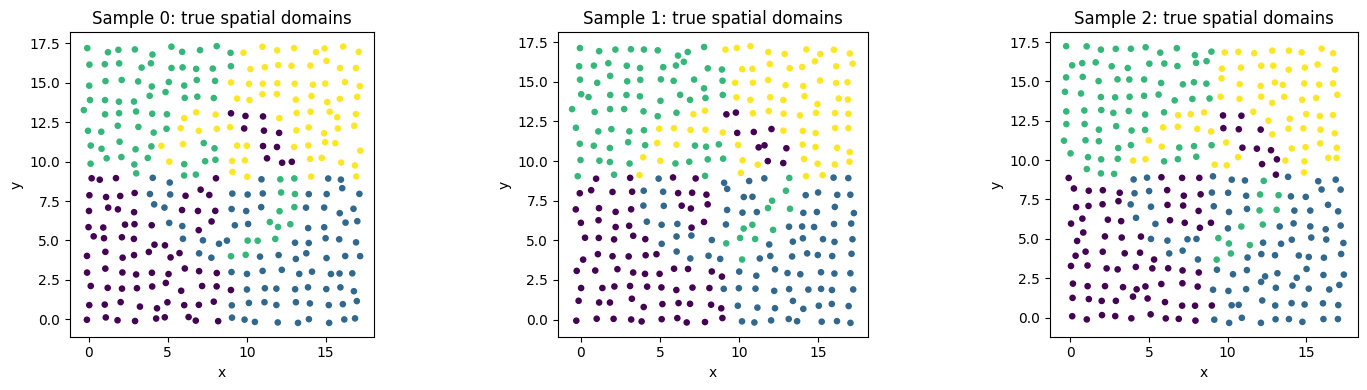

In [4]:
fig, axes = plt.subplots(1, NUM_SAMPLES, figsize=(5 * NUM_SAMPLES, 4))

if NUM_SAMPLES == 1:
    axes = [axes]

offset = 0
for sid, ax in enumerate(axes):
    coords = coords_list[sid]
    n = coords.shape[0]
    labels = true_labels[offset:offset+n]
    ax.scatter(coords[:, 0], coords[:, 1], c=labels, s=14)
    ax.set_title(f"Sample {sid}: true spatial domains")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")
    offset += n

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "simulated_true_domains.png"), dpi=300, bbox_inches="tight")
plt.show()

## 5. Show the observed batch effect before training
These PCA plots use the raw simulated features. If the batch effect is strong, points should separate by sample even though the underlying biology is shared.

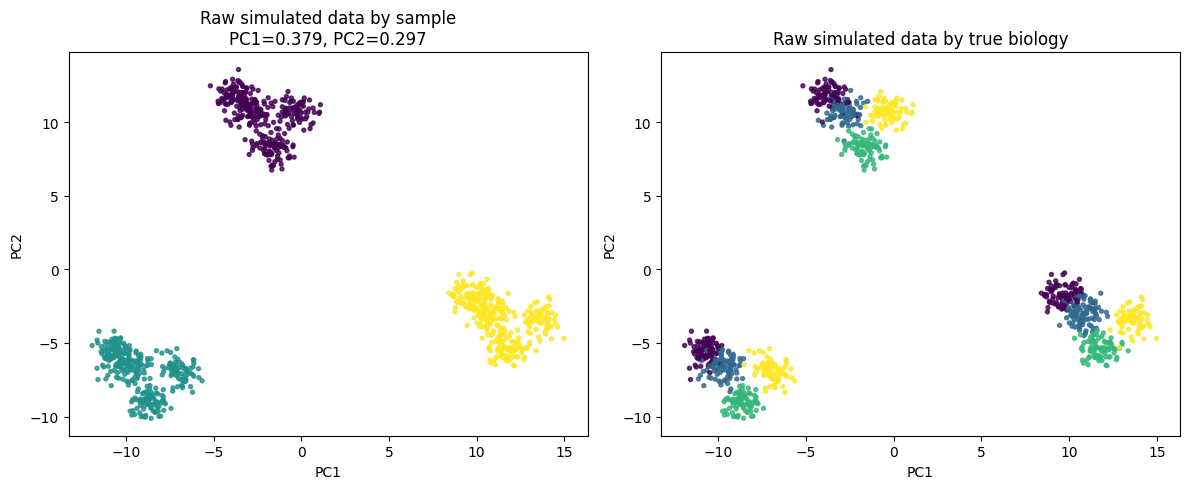

In [5]:
raw_concat = np.concatenate([X_rna_all, X_prot_all], axis=1)
raw2, raw_exp = pca_projection(raw_concat)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(raw2[:, 0], raw2[:, 1], c=sample_ids, s=8, alpha=0.8)
axes[0].set_title(f"Raw simulated data by sample\nPC1={raw_exp[0]:.3f}, PC2={raw_exp[1]:.3f}")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

axes[1].scatter(raw2[:, 0], raw2[:, 1], c=true_labels, s=8, alpha=0.8)
axes[1].set_title("Raw simulated data by true biology")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "raw_simulated_pca.png"), dpi=300, bbox_inches="tight")
plt.show()

## 6. Build disconnected graphs across samples
Each sample keeps its own internal spatial and feature graph, but all samples are trained together with shared encoder weights.

In [6]:
spatial_edge_index = build_disconnected_spatial_graph(coords_list, k=SPATIAL_K)
rna_feature_edge_index = build_disconnected_feature_graph(X_rna_list, k=FEATURE_K)
prot_feature_edge_index = build_disconnected_feature_graph(X_prot_list, k=FEATURE_K)

X_rna_t = torch.tensor(X_rna_all, dtype=torch.float32)
X_prot_t = torch.tensor(X_prot_all, dtype=torch.float32)
sample_ids_t = torch.tensor(sample_ids, dtype=torch.long)

print("Spatial edges:", spatial_edge_index.shape)
print("RNA feature edges:", rna_feature_edge_index.shape)
print("Protein feature edges:", prot_feature_edge_index.shape)

Spatial edges: torch.Size([2, 5832])
RNA feature edges: torch.Size([2, 9720])
Protein feature edges: torch.Size([2, 9720])


## 7. Train the model without batch correction
This version omits the MMD term.

In [7]:
model_no_batch = SpatialGlueMini(
    in_dim=IN_DIM,
    hidden_dim=HIDDEN_DIM,
    latent_dim=LATENT_DIM,
    num_modalities=2,
    dropout=0.1,
)

model_no_batch, history_no_batch = train_with_history(
    model_no_batch,
    xs=[X_rna_t, X_prot_t],
    spatial_edge_index=spatial_edge_index,
    feature_edge_indices=[rna_feature_edge_index, prot_feature_edge_index],
    sample_ids=None,
    epochs=EPOCHS,
    lr=LR,
    lambda_corr=LAMBDA_CORR,
    lambda_batch=0.0,
    device=DEVICE,
)

Z_no_batch, outputs_no_batch = get_latent(
    model_no_batch,
    [X_rna_t, X_prot_t],
    spatial_edge_index,
    [rna_feature_edge_index, prot_feature_edge_index],
)

Epoch 0001 | total=15.2080 | recon=10.4181 | corr=4.7899 | batch=0.0000
Epoch 0050 | total=3.2304 | recon=2.8972 | corr=0.3332 | batch=0.0000
Epoch 0100 | total=1.9855 | recon=1.8182 | corr=0.1673 | batch=0.0000
Epoch 0150 | total=1.4319 | recon=1.2842 | corr=0.1477 | batch=0.0000
Epoch 0200 | total=1.1926 | recon=1.0453 | corr=0.1473 | batch=0.0000
Epoch 0250 | total=1.0919 | recon=0.9612 | corr=0.1307 | batch=0.0000
Epoch 0300 | total=1.0112 | recon=0.8952 | corr=0.1160 | batch=0.0000
Epoch 0350 | total=0.9663 | recon=0.8612 | corr=0.1051 | batch=0.0000
Epoch 0400 | total=0.9243 | recon=0.8338 | corr=0.0904 | batch=0.0000


## 8. Train the model with MMD batch correction
This version uses the same architecture but turns on the MMD batch-alignment term.

In [8]:
model_batch = SpatialGlueMini(
    in_dim=IN_DIM,
    hidden_dim=HIDDEN_DIM,
    latent_dim=LATENT_DIM,
    num_modalities=2,
    dropout=0.1,
)

model_batch, history_batch = train_with_history(
    model_batch,
    xs=[X_rna_t, X_prot_t],
    spatial_edge_index=spatial_edge_index,
    feature_edge_indices=[rna_feature_edge_index, prot_feature_edge_index],
    sample_ids=sample_ids_t,
    epochs=EPOCHS,
    lr=LR,
    lambda_corr=LAMBDA_CORR,
    lambda_batch=LAMBDA_BATCH,
    device=DEVICE,
)

Z_batch, outputs_batch = get_latent(
    model_batch,
    [X_rna_t, X_prot_t],
    spatial_edge_index,
    [rna_feature_edge_index, prot_feature_edge_index],
)

Epoch 0001 | total=14.3293 | recon=10.3872 | corr=3.8454 | batch=0.1935
Epoch 0050 | total=3.7649 | recon=3.2610 | corr=0.4021 | batch=0.2036
Epoch 0100 | total=2.0871 | recon=1.8079 | corr=0.1919 | batch=0.1746
Epoch 0150 | total=1.5150 | recon=1.2877 | corr=0.1681 | batch=0.1184
Epoch 0200 | total=1.3108 | recon=1.1001 | corr=0.1559 | batch=0.1098
Epoch 0250 | total=1.2249 | recon=1.0256 | corr=0.1409 | batch=0.1166
Epoch 0300 | total=1.1772 | recon=0.9801 | corr=0.1355 | batch=0.1232
Epoch 0350 | total=1.1341 | recon=0.9354 | corr=0.1341 | batch=0.1292
Epoch 0400 | total=1.0878 | recon=0.8793 | corr=0.1365 | batch=0.1441


## 9. Compare training curves
The batch-aware model should show a non-zero batch term and often a different total-loss trajectory.

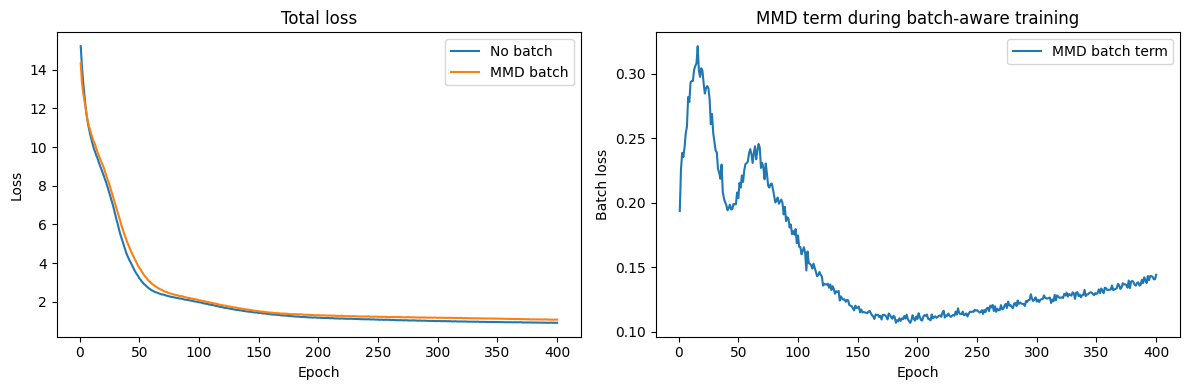

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_no_batch["epoch"], history_no_batch["total"], label="No batch")
axes[0].plot(history_batch["epoch"], history_batch["total"], label="MMD batch")
axes[0].set_title("Total loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history_batch["epoch"], history_batch["batch"], label="MMD batch term")
axes[1].set_title("MMD term during batch-aware training")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Batch loss")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "training_curves.png"), dpi=300, bbox_inches="tight")
plt.show()

## 10. Compare latent spaces
These PCA projections test whether MMD reduces separation by sample while preserving organization by biological domain.

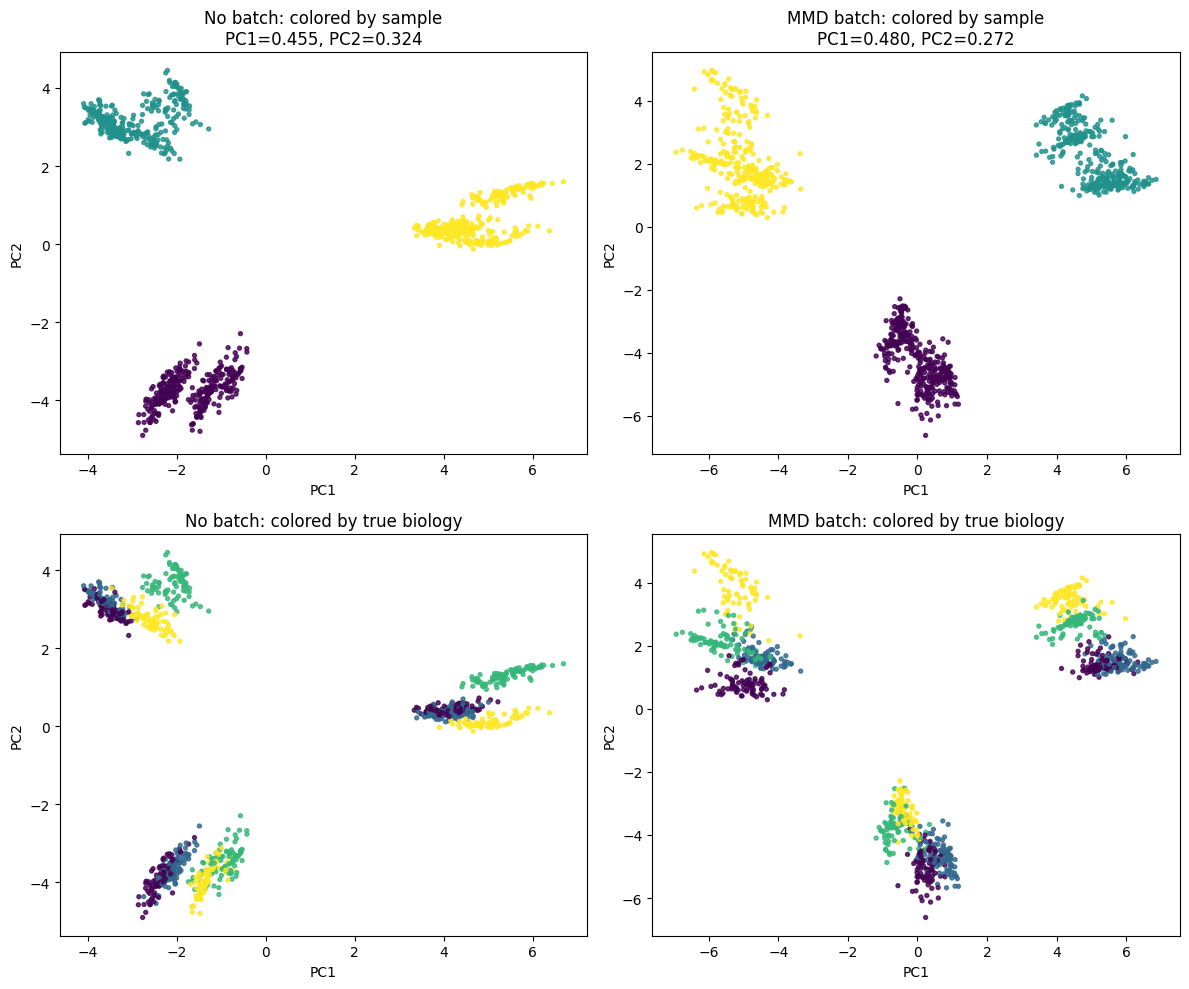

In [10]:
Z2_no_batch, exp_no_batch = pca_projection(Z_no_batch)
Z2_batch, exp_batch = pca_projection(Z_batch)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].scatter(Z2_no_batch[:, 0], Z2_no_batch[:, 1], c=sample_ids, s=8, alpha=0.8)
axes[0, 0].set_title(f"No batch: colored by sample\nPC1={exp_no_batch[0]:.3f}, PC2={exp_no_batch[1]:.3f}")
axes[0, 0].set_xlabel("PC1")
axes[0, 0].set_ylabel("PC2")

axes[0, 1].scatter(Z2_batch[:, 0], Z2_batch[:, 1], c=sample_ids, s=8, alpha=0.8)
axes[0, 1].set_title(f"MMD batch: colored by sample\nPC1={exp_batch[0]:.3f}, PC2={exp_batch[1]:.3f}")
axes[0, 1].set_xlabel("PC1")
axes[0, 1].set_ylabel("PC2")

axes[1, 0].scatter(Z2_no_batch[:, 0], Z2_no_batch[:, 1], c=true_labels, s=8, alpha=0.8)
axes[1, 0].set_title("No batch: colored by true biology")
axes[1, 0].set_xlabel("PC1")
axes[1, 0].set_ylabel("PC2")

axes[1, 1].scatter(Z2_batch[:, 0], Z2_batch[:, 1], c=true_labels, s=8, alpha=0.8)
axes[1, 1].set_title("MMD batch: colored by true biology")
axes[1, 1].set_xlabel("PC1")
axes[1, 1].set_ylabel("PC2")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "latent_pca_comparison.png"), dpi=300, bbox_inches="tight")
plt.show()

## 11. Quantitative evaluation
Here, lower batch silhouette is better for mixing, higher batch entropy is better for mixing, and higher ARI/NMI/biology silhouette means better recovery of the true biological domains.

In [11]:
metrics_no_batch, pred_no_batch = evaluate_embedding(Z_no_batch, sample_ids, true_labels)
metrics_batch, pred_batch = evaluate_embedding(Z_batch, sample_ids, true_labels)
metrics_raw, pred_raw = evaluate_embedding(raw_concat, sample_ids, true_labels)

results_df = pd.DataFrame([
    {"method": "Raw simulated features", **metrics_raw},
    {"method": "No batch correction", **metrics_no_batch},
    {"method": "MMD batch correction", **metrics_batch},
])

for col in results_df.columns:
    if col != "method":
        results_df[col] = results_df[col].astype(float)

display(results_df.round(4))
results_df.round(6).to_csv(os.path.join(TABLE_DIR, "simulation_metrics.csv"), index=False)

,method,batch_silhouette,biology_silhouette,batch_entropy,ARI_vs_truth,NMI_vs_truth
0,Raw simulated features,0.4898,0.1557,0.0,0.0692,0.1704
1,No batch correction,0.5954,0.1721,0.0,0.0692,0.1704
2,MMD batch correction,0.5433,0.1726,0.0,0.0682,0.1662


## 12. Per-sample latent centroids
If MMD works, the sample centroids in latent PCA space should usually move closer together.

In [12]:
centroids_no_batch = sample_centroid_table(Z2_no_batch, sample_ids)
centroids_batch = sample_centroid_table(Z2_batch, sample_ids)

print("No-batch centroids:")
display(centroids_no_batch.round(4))
print("MMD centroids:")
display(centroids_batch.round(4))

centroids_no_batch.round(6).to_csv(os.path.join(TABLE_DIR, "centroids_no_batch.csv"), index=False)
centroids_batch.round(6).to_csv(os.path.join(TABLE_DIR, "centroids_batch.csv"), index=False)

No-batch centroids:


,sample,PC1_centroid,PC2_centroid
0,0,-1.6980,-3.7249
1,1,-2.9645,3.1522
2,2,4.6625,0.5727


MMD centroids:


,sample,PC1_centroid,PC2_centroid
0,0,0.0109,-4.2191
1,1,5.0366,2.2161
2,2,-5.0474,2.0029


## 13. Cluster agreement with the ground truth
These tables compare learned cluster labels to the known synthetic biology.

In [13]:
cluster_comp = pd.DataFrame({
    "sample_id": sample_ids,
    "true_label": true_labels,
    "pred_raw": pred_raw,
    "pred_no_batch": pred_no_batch,
    "pred_mmd": pred_batch,
})

print("Counts by sample and true label:")
display(pd.crosstab(cluster_comp["sample_id"], cluster_comp["true_label"]))

print("Counts by sample and predicted cluster (no batch):")
display(pd.crosstab(cluster_comp["sample_id"], cluster_comp["pred_no_batch"]))

print("Counts by sample and predicted cluster (MMD):")
display(pd.crosstab(cluster_comp["sample_id"], cluster_comp["pred_mmd"]))

cluster_comp.to_csv(os.path.join(TABLE_DIR, "cluster_assignments.csv"), index=False)

Counts by sample and true label:


true_label,0,1,2,3
sample_id,,,,
0,86,84,82,72
1,84,87,82,71
2,85,89,83,67


Counts by sample and predicted cluster (no batch):


pred_no_batch,0,1,2,3
sample_id,,,,
0,0,324,0,0
1,0,0,166,158
2,324,0,0,0


Counts by sample and predicted cluster (MMD):


pred_mmd,0,1,2,3
sample_id,,,,
0,0,0,324,0
1,167,0,0,157
2,0,324,0,0


## 14. Save models and embeddings

In [14]:
np.save(os.path.join(MODEL_DIR, "Z_no_batch.npy"), Z_no_batch)
np.save(os.path.join(MODEL_DIR, "Z_batch.npy"), Z_batch)
np.save(os.path.join(MODEL_DIR, "sample_ids.npy"), sample_ids)
np.save(os.path.join(MODEL_DIR, "true_labels.npy"), true_labels)

torch.save(model_no_batch.state_dict(), os.path.join(MODEL_DIR, "model_no_batch.pt"))
torch.save(model_batch.state_dict(), os.path.join(MODEL_DIR, "model_batch.pt"))

print("Saved embeddings, labels, and models.")

Saved embeddings, labels, and models.


# Final interpretation guide

Use the results this way:

- **If MMD is working**, you want:
  - **lower** `batch_silhouette`
  - **higher** `batch_entropy`
  - sample-colored PCA plots to look **more mixed**
  - while `ARI_vs_truth`, `NMI_vs_truth`, and `biology_silhouette` stay stable or improve

- **If MMD over-corrects**, you may see:
  - better batch mixing
  - but worse ARI/NMI or weaker biology separation

- **If MMD is not doing much**, the no-batch and MMD metrics/plots will remain very similar

Because this is simulated data with known truth, this notebook gives a much cleaner test of whether the MMD term is helping than the original real-data notebook.